# **APE12_Análisis Bivariado y Predicción/GrupoD**
# 🧠 **Integrantes:**

*   Noelia Bustan
*   Alison Tapia
*   Christofer Pineda
*   Elian Jimenez
*   Yimmy Angulo
-----------------


## 📝 **Introducción**

En el presente trabajo se aplicaron técnicas de inferencia estadística utilizando Python y Jupyter Notebook sobre un dataset real de casos de dengue. El objetivo fue estimar parámetros poblacionales a partir de muestras y analizar la incertidumbre asociada a dichas estimaciones.

Para ello, se calcularon intervalos de confianza para la media empleando tanto la distribución Normal Estándar (Z) en muestras grandes como la distribución T de Student en muestras pequeñas. Además, se analizó el efecto que tiene el nivel de confianza sobre el margen de error y se aplicaron estos conceptos a una variable cuantitativa del proyecto integrador.

Los resultados obtenidos permitieron comprender la importancia de la estimación por intervalos en la toma de decisiones, así como la relación existente entre tamaño de muestra, nivel de confianza y precisión de las estimaciones estadísticas.

---
# **🛠️ Análisis de Correlación de Pearson**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
# Generación de datos simulados (Relación positiva fuerte con ruido)
np.random.seed(42)
usuarios_X = np.random.randint(50, 500, size=100)

# Y = 2.5*X + 50 + Ruido Aleatorio
ancho_banda_Y = 2.5 * usuarios_X + 50 + np.random.normal(0, 100, size=100)

# 1. Cálculo del Coeficiente de Pearson y su valor-p
coef_pearson, p_valor = pearsonr(usuarios_X, ancho_banda_Y)

print("--- Análisis de Correlación de Pearson ---")
print(f"Coeficiente (r): {coef_pearson:.4f}")
print(f"Valor-p (Significancia): {p_valor:.4e}")

if p_valor < 0.05:
  print("Conclusión: Existe una correlación lineal estadísticamente significativa.")
else:
  print("Conclusión: NO existe evidencia de correlación lineal significativa.")

  # 2. Visualización: Diagrama de Dispersión (Scatter Plot)
  plt.figure(figsize=(8, 5))
  sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, color='blue', alpha=0.7)
  plt.title(f'Dispersión: Usuarios vs Ancho de Banda (r = {coef_pearson:.2f})')
  plt.xlabel('Usuarios Concurrentes (X)')
  plt.ylabel('Ancho de Banda Mbps (Y)')
  plt.grid(True, linestyle='--', alpha=0.5)
  plt.show()

--- Análisis de Correlación de Pearson ---
Coeficiente (r): 0.9603
Valor-p (Significancia): 3.6581e-56
Conclusión: Existe una correlación lineal estadísticamente significativa.


---
# **🛠️ Tarea 2: Ajuste del Modelo de Regresión Lineal Simple (OLS)**

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.922
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     1163.
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.66e-56
Time:                        13:01:47   Log-Likelihood:                -597.28
No. Observations:                 100   AIC:                             1199.
Df Residuals:                      98   BIC:                             1204.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.6745     23.385      1.226      0.2

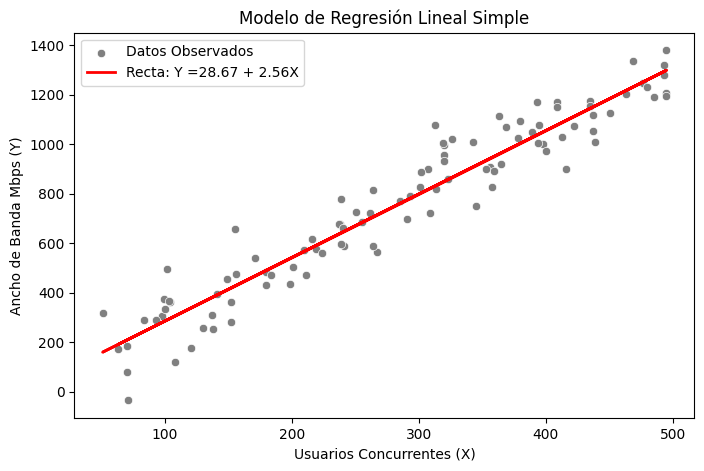

In [ ]:
import statsmodels.api as sm

# Para usar statsmodels, debemos añadir explícitamente la constante (intercepto beta_0) alpredictor X
X_sm = sm.add_constant(usuarios_X)
Y_sm = ancho_banda_Y

# Ajuste del modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_ols = sm.OLS(Y_sm, X_sm).fit()

# Impresión del resumen estadístico
print(modelo_ols.summary())

# Extracción de parámetros para graficar la recta
beta_0 = modelo_ols.params[0]
beta_1 = modelo_ols.params[1]

plt.figure(figsize=(8, 5))
sns.scatterplot(x=usuarios_X, y=ancho_banda_Y, label='Datos Observados', color='gray')
# Dibujo de la recta de regresión
plt.plot(usuarios_X, beta_0 + beta_1 * usuarios_X, color='red', linewidth=2, label=f'Recta: Y ={beta_0:.2f} + {beta_1:.2f}X')
plt.title('Modelo de Regresión Lineal Simple')
plt.xlabel('Usuarios Concurrentes (X)')
plt.ylabel('Ancho de Banda Mbps (Y)')
plt.legend()
plt.show()

---
# **🛠️ Tarea 3: Hito del Proyecto - Predicción en el DatasetRegional (ABP)**

La columna 'Total' existe pero no parece ser la suma de los casos por edad/género. Recalculando.

ANÁLISIS DE CORRELACIÓN DE PEARSON
Coeficiente de Pearson (r): -0.0305
Valor-p para Pearson: 0.0000
Conclusión: Existe una correlación lineal estadísticamente significativa entre la Semana y el Total de casos de dengue.

RESUMEN DEL MODELO DE REGRESIÓN LINEAL (OLS)
                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     33.27
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           8.10e-09
Time:                        13:27:18   Log-Likelihood:                -75643.
No. Observations:               35749   AIC:                         1.513e+05
Df Residuals:                   35747   BIC:                         1.513e+05
Df M

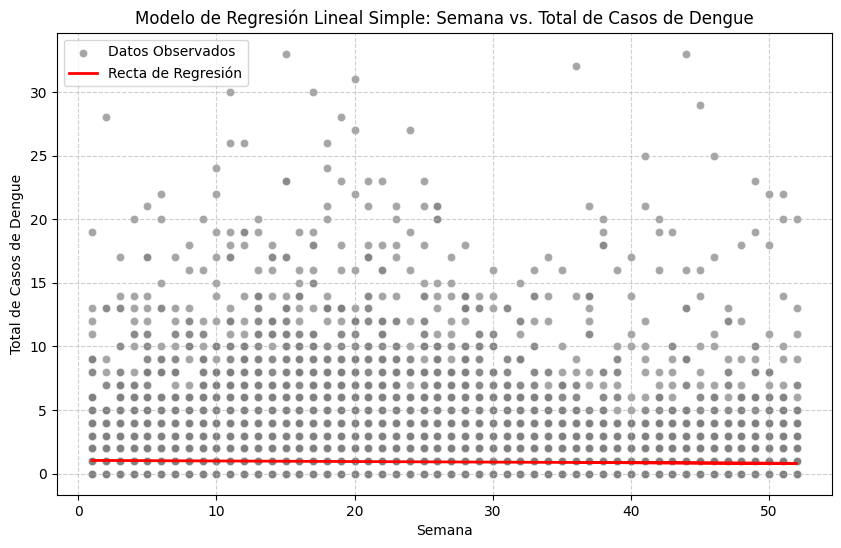

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# TAREA 3: PREDICCIÓN EN EL DATASET REGIONAL (ABP)
# ==========================================================

# 1. Importar el dataset regional
try:
    df = pd.read_excel(
        "Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx",
        sheet_name="DSSA_2021_2024"
    )
except NameError:
    print("DataFrame 'df' not found, loading from file.")
    df = pd.read_excel(
        "Datos_Dengue_MSP_Ene2021_Ago2025(2).xlsx",
        sheet_name="DSSA_2021_2024"
    )

# Se asume que las columnas con formato 'X - Y H/M' son las que contienen el conteo de casos.
columnas_casos = [col for col in df.columns if any(s in col for s in [' H', ' M']) and (' - ' in col or '+' in col)]

# Sumar las columnas de casos para obtener el 'Total'
if 'Total' not in df.columns:
    df['Total'] = df[columnas_casos].sum(axis=1)
elif not df['Total'].equals(df[columnas_casos].sum(axis=1)):
    # Si 'Total' existe pero no es la suma de las columnas de casos, recalcularla
    print("La columna 'Total' existe pero no parece ser la suma de los casos por edad/género. Recalculando.")
    df['Total'] = df[columnas_casos].sum(axis=1)


# 2. Identificar variable independiente (X) y dependiente (Y)
X = df['Semana'].astype(float) # Variable predictora: Semana
Y = df['Total'].astype(float)  # Variable respuesta: Total de casos de dengue

# Cálculo del Coeficiente de Pearson y su valor-p
coef_pearson, p_valor_pearson = pearsonr(X, Y)
print("\n" + "="*65)
print("ANÁLISIS DE CORRELACIÓN DE PEARSON")
print("="*65)
print(f"Coeficiente de Pearson (r): {coef_pearson:.4f}")
print(f"Valor-p para Pearson: {p_valor_pearson:.4f}")

if p_valor_pearson < 0.05:
  print("Conclusión: Existe una correlación lineal estadísticamente significativa entre la Semana y el Total de casos de dengue.")
else:
  print("Conclusión: NO existe evidencia de correlación lineal significativa entre la Semana y el Total de casos de dengue.")
print("="*65)

# Ajuste del modelo OLS
X_ols = sm.add_constant(X)
modelo_ols = sm.OLS(Y, X_ols).fit()

# Imprimir el resumen estadístico
print("\n" + "="*65)
print("RESUMEN DEL MODELO DE REGRESIÓN LINEAL (OLS)")
print("="*65)
print(modelo_ols.summary())
print("="*65)

# Elegir un valor de Semana que no esté en el dataset original para pronóstico.
valor_critico_semana = X.max() + 1

# Calcular el valor esperado de Y para el valor crítico de X
x_prediccion = pd.DataFrame({'const': [1], 'Semana': [valor_critico_semana]})

y_predicho = modelo_ols.predict(x_prediccion)[0]

print("\n" + "="*65)
print("PREDICCIÓN")
print("="*65)
print(f"Valor crítico de Semana (X): {valor_critico_semana}")
print(f"Valor esperado de Casos Totales (Y) para la Semana {valor_critico_semana}: {y_predicho:.2f}")
print("="*65)

# Visualización de la regresión
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=Y, label='Datos Observados', color='gray', alpha=0.7)
plt.plot(X, modelo_ols.predict(X_ols), color='red', linewidth=2, label='R0ecta de Regresión')
plt.title('Modelo de Regresión Lineal Simple: Semana vs. Total de Casos de Dengue')
plt.xlabel('Semana')
plt.ylabel('Total de Casos de Dengue')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Interpretación del Coeficiente de Determinación (R-squared)**

El coeficiente de determinación (R-squared) obtenido del modelo OLS es `0.001`.

**Interpretación:**

Este valor indica que aproximadamente el **0.1%** de la variabilidad total en el número de casos de dengue (`Total`) puede ser explicada por la variable `Semana`.

Desde una **perspectiva de negocio o salud pública**, un R-squared tan bajo (cercano a cero) sugiere que el modelo de regresión lineal simple, utilizando únicamente la variable `Semana` como predictor, tiene una **capacidad predictiva muy limitada** para explicar las fluctuaciones en el número de casos de dengue. En otras palabras, `Semana` por sí sola no es un buen predictor del `Total` de casos en este dataset.

Esto implica que:

*   **El modelo no es adecuado para pronósticos precisos:** No se debería confiar en este modelo para predecir de manera efectiva el número de casos futuros basándose solo en la semana.
*   **Existen otras variables importantes:** La mayor parte de la variabilidad en los casos de dengue se debe a factores no incluidos en este modelo (como clima, densidad poblacional, medidas de control, presencia del vector, etc.).
*   **Necesidad de un modelo más complejo:** Para mejorar la capacidad predictiva, sería necesario incorporar más variables predictoras relevantes (regresión múltiple) o considerar modelos no lineales si la relación no es lineal.

En resumen, aunque la correlación fue estadísticamente significativa (debido al gran tamaño de la muestra, lo que puede detectar efectos muy pequeños), la **significancia práctica** de la `Semana` como predictor único del `Total` de casos es **extremadamente baja**.